In [ ]:
!sudo apt update && sudo apt install -y tesseract-ocr

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,816 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,429 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Pack

In [ ]:
!pip install pytesseract pillow pandas

In [ ]:
!pip install easynmt deep-translator transformers torch

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 6.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.5 MB/s eta 0:00:00
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for easynmt: filename=EasyNMT-2.0.2-py3-none-any.whl size=19898 sha256=0057b9e21b7c6ab95b199734aec1c258a3e477d17fcc84ff6e0fe1fb2e1553e6
  Stored in directory: /root/.cache/pip/wheels/1c/5c/5d/d698bb79f4c9ddc0b910bb71d1ddb9048fb3bc7b0ed7ce40ea
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498214 sha256=ba5b2d5d320f7563440b04dc22c95b676f97dbe896e0623d9a3d84ce45bee469
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully

In [ ]:
!pip install langdetect deep-translator easynmt reportlab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 64.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 108.2 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=7fea64b6ebc79cad299df88d2781ccf0315ec2f705044b36a2276eed21a2159c
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
!pip install sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 53.4 MB/s eta 0:00:00


In [ ]:
!pip install langdetect deep-translator easynmt reportlab nltk --quiet

In [ ]:
# STEP 2: Import dependencies

from google.colab import files
from PIL import Image, ImageDraw, ImageFont
import pytesseract
import pandas as pd
import json
import shutil, subprocess
import os

# STEP 3: Define save directory in Drive

save_dir = "/content/drive/MyDrive/Mediaura"
os.makedirs(save_dir, exist_ok=True)
print(f"📁 All results will be saved in: {save_dir}")

# STEP 4: Upload image

print("📤 Please upload your image file (e.g., .jpg, .png, .jpeg)")
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
print(f"✅ Image uploaded successfully: {img_path}")


# STEP 5: Check Tesseract binary

print("Tesseract path:", shutil.which('tesseract'))
print("Tesseract version:", subprocess.check_output(['tesseract','--version']).decode().splitlines()[0])


# STEP 6: Load uploaded image

img = Image.open(img_path).convert('RGB')


# STEP 7: Preprocess for better OCR

gray = img.convert('L')
scale = 2
gray_resized = gray.resize((img.width * scale, img.height * scale))
bw = gray_resized.point(lambda p: 255 if p > 150 else 0)

preprocessed_path = os.path.join(save_dir, "ocr_preprocessed.png")
bw.save(preprocessed_path)
print(f"✅ Preprocessed image saved at: {preprocessed_path}")

# STEP 8: Run Tesseract OCR

config = '--oem 3 --psm 6'
data = pytesseract.image_to_data(
    bw, output_type=pytesseract.Output.DICT, config=config, lang='eng'
)

df = pd.DataFrame(data)
df = df[df['text'].notnull() & (df['text'].str.strip() != "")]
df['conf'] = pd.to_numeric(df['conf'], errors='coerce').fillna(-1).astype(float)

# STEP 9: Group words into lines

lines = []
for gkey, g in df.groupby(['page_num', 'block_num', 'par_num', 'line_num']):
    left = int(g['left'].min())
    top = int(g['top'].min())
    right = int((g['left'] + g['width']).max())
    bottom = int((g['top'] + g['height']).max())
    text = " ".join(g['text'].tolist())
    conf = float(g['conf'].mean())
    lines.append({
        'page_num': int(gkey[0]),
        'block_num': int(gkey[1]),
        'par_num': int(gkey[2]),
        'line_num': int(gkey[3]),
        'left': int(left / scale),
        'top': int(top / scale),
        'right': int(right / scale),
        'bottom': int(bottom / scale),
        'text': text,
        'conf': conf
    })

# STEP 10: Draw bounding boxes

overlay = img.copy()
draw = ImageDraw.Draw(overlay)
for i, r in enumerate(lines):
    bbox = [r['left'], r['top'], r['right'], r['bottom']]
    color = (0, 255, 0) if r['conf'] > 40 else (255, 0, 0)
    draw.rectangle(bbox, outline=color, width=2)
    draw.text((bbox[0] + 2, bbox[1] + 2), f"{i}: {int(r['conf'])}", fill=color)

overlay_path = os.path.join(save_dir, "ocr_tesseract_overlay.png")
overlay.save(overlay_path)
print(f"✅ Overlay image saved at: {overlay_path}")

# STEP 11: Save JSON results

json_path = os.path.join(save_dir, "parsed_tesseract.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(lines, f, indent=2, ensure_ascii=False)
print(f"✅ JSON results saved at: {json_path}")

# STEP 12: Preview extracted text

print("\n🧾 Sample extracted text:")
for line in lines[:10]:
    print("-", line['text'])

print("\n🎉 All files saved successfully to your Google Drive folder!")


📁 All results will be saved in: /content/drive/MyDrive/Mediaura
📤 Please upload your image file (e.g., .jpg, .png, .jpeg)


Saving Sample_report_NLP (1)_page-0001 (1).jpg to Sample_report_NLP (1)_page-0001 (1).jpg
✅ Image uploaded successfully: Sample_report_NLP (1)_page-0001 (1).jpg
Tesseract path: /usr/bin/tesseract
Tesseract version: tesseract 4.1.1
✅ Preprocessed image saved at: /content/drive/MyDrive/Mediaura/ocr_preprocessed.png
✅ Overlay image saved at: /content/drive/MyDrive/Mediaura/ocr_tesseract_overlay.png
✅ JSON results saved at: /content/drive/MyDrive/Mediaura/parsed_tesseract.json

🧾 Sample extracted text:
- Nisaesve)o) mimes UIMIMII(IINIINII ANTI IM
- papers 25006 7506? 14360
- Name : Mr. PANDHARINATH SAKHARAM PARAB VID No. : 250067506214 360
- Age / Gender :80.3 Year(s)/ Male PID No. :P15723514861117
- Contact No. :+919029692935 Referred by : DR.NAVEEN SIVAKUTTY
- Address > LOKHANDWALA KandivaliEast.. Sample Collected At . Cghs Mumbai Credit. Cghs Mumbai Credit Gr Floor Paathishtha
- Pin code :400101 Bhavan. 400020. 27-mh 400020 India
- SUMMARY REPORT
- investigation Outside Reference Range 

In [ ]:
# STEP 0: Install dependencies

!pip install deep-translator --quiet

# STEP 1: Imports

import json
from deep_translator import GoogleTranslator

# STEP 2: Load parsed OCR JSON

json_path = "/content/drive/MyDrive/Mediaura/parsed_tesseract.json"
with open(json_path, "r", encoding="utf-8") as f:
    lines = json.load(f)

# STEP 3: Translate line by line

translator = GoogleTranslator(source='en', target='hi')

hindi_lines = []
for ln in lines:
    text = ln['text']
    # Skip empty lines
    if text.strip() == "":
        continue
    try:
        # Translate only if line has more than 3 words (skip codes/names mostly)
        if len(text.split()) > 3:
            translated = translator.translate(text)
        else:
            translated = text  # preserve short codes/names as is
    except Exception:
        translated = text  # fallback to original if translation fails
    hindi_lines.append(translated)

# STEP 4: Combine translated lines

full_hindi_report = "\n".join(hindi_lines)

# STEP 5: Optional - Detect abnormal values summary

abnormal_keywords = ["Haemoglobin", "PCV", "RDW", "Platelet", "Bilirubin"]
abnormals = [ln['text'] for ln in lines if any(k in ln['text'] for k in abnormal_keywords)]
summary_en = "The report shows abnormal values for: " + "; ".join(abnormals) if abnormals else "No abnormal values detected."
summary_hi = translator.translate(summary_en) if abnormals else "रिपोर्ट में कोई असामान्य मान नहीं पाए गए।"

# STEP 6: Display results

print("🧾 Hindi Abnormal Summary:\n", summary_hi)
print("\n🧾 Hindi Full Report Preview:\n")
print(full_hindi_report[:1000], "...")


🧾 Hindi Abnormal Summary:
 रिपोर्ट असामान्य मान दिखाती है: हीमोग्लोबिन (एचबी) 12.2 ग्राम/डीएल 14-18; पीसीवी (पैक्ड सेल वॉल्यूम) 375% 42-52; आरडीडब्ल्यू (लाल कोशिका वितरण चौड़ाई) 19.6% 11.5-14.0; प्लेटलेट्स; पीसीटी (प्लेटलेट क्रिट) 0.102 % 0.2-0.5; पीडीडब्ल्यू (प्लेटलेट वितरण चौड़ाई) 17.4% 9-17; बिलीरुबिन डायरेक्ट 0.33 मिलीग्राम/डीएल 0.0-0.3

🧾 Hindi Full Report Preview:

Nisaesve)o) mimes UIMIMII(IINIINII ANTI IM
कागजात 25006 7506? 14360
नाम: श्री पंढरीनाथ सखाराम परब वीडियो नंबर: 250067506214 360
आयु/लिंग :80.3 वर्ष/पुरुष पीआईडी ​​संख्या :पी15723514861117
संपर्क नंबर :+919029692935 संदर्भित : डॉ.नवीन शिवकुट्टी
पता > लोखंडवाला कांदिवलीईस्ट.. नमूना एकत्र किया गया। सीजीएचएस मुंबई क्रेडिट। सीजीएचएस मुंबई क्रेडिट जीआर फ्लोर पथिष्ठा
पिन कोड :400101 भवन। 400020. 27-एमएच 400020 भारत
SUMMARY REPORT
संदर्भ सीमा के बाहर जांच (असामान्य)
जांच अवलोकित मूल्य इकाई जैविक संदर्भ अंतराल
CBC Haemogram
Erythrocytes
(ईडीटीए संपूर्ण रक्त)
हीमोग्लोबिन (एचबी) 12.2 ग्राम/डीएल 14-18
पीसीवी (पैक्ड सेल वॉल्यूम) 37

In [ ]:
# ==========================================
# STEP: Evaluate Performance Metrics
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
from deep_translator import GoogleTranslator
import difflib
import statistics

# 1️⃣ OCR Accuracy Evaluation (using ground truth text if available)
# --------------------------------------------------
# If you have manually verified lines, place them in 'ground_truth_texts'
# Example: ground_truth_texts = ["Patient Name: X", "Age: 45", ...]
# Here we just simulate ground truth for demonstration.

ground_truth_texts = ["Haemoglobin 12.2 g/dL", "PCV 37.5%", "Bilirubin Direct 0.33 mg/dL"]
ocr_texts = [ln['text'] for ln in lines[:len(ground_truth_texts)]]

similarities = [difflib.SequenceMatcher(None, gt, ocr).ratio() for gt, ocr in zip(ground_truth_texts, ocr_texts)]
ocr_accuracy = np.mean(similarities) * 100

print(f"📊 OCR Text Similarity Accuracy: {ocr_accuracy:.2f}%")

# 2️⃣ Translation Quality Evaluation (using BLEU-like similarity)
# --------------------------------------------------
# Compare English original and back-translated Hindi text to measure consistency.

translator = GoogleTranslator(source='hi', target='en')
back_translations = [translator.translate(txt) for txt in hindi_lines[:10]]
bleu_like_scores = [difflib.SequenceMatcher(None, orig, back).ratio() for orig, back in zip(ocr_texts[:10], back_translations)]
translation_consistency = statistics.mean(bleu_like_scores) * 100

print(f"🈶 Translation Consistency (Back-Translation BLEU-like): {translation_consistency:.2f}%")

# 3️⃣ Predictive Analysis Evaluation (trend reliability)
# --------------------------------------------------
# Simulate predictions: compare predicted abnormal results vs. actual flagged ones.

predicted_abnormals = ["Haemoglobin", "PCV", "RDW", "Bilirubin"]
actual_abnormals = [k for k in abnormal_keywords if any(k in a for a in abnormals)]

# Binary match vectors
pred_bin = [1 if k in predicted_abnormals else 0 for k in abnormal_keywords]
actual_bin = [1 if k in actual_abnormals else 0 for k in abnormal_keywords]

precision = precision_score(actual_bin, pred_bin, zero_division=0)
recall = recall_score(actual_bin, pred_bin, zero_division=0)
f1 = f1_score(actual_bin, pred_bin, zero_division=0)

print("\n📈 Predictive Analysis Metrics:")
print(f"   Precision: {precision:.2f}")
print(f"   Recall:    {recall:.2f}")
print(f"   F1 Score:  {f1:.2f}")

# 4️⃣ Overall System Performance Summary
# --------------------------------------------------
overall_score = (ocr_accuracy * 0.4) + (translation_consistency * 0.3) + (f1 * 100 * 0.3)
print(f"\n🏁 Overall System Performance Score: {overall_score:.2f}/100")


📊 OCR Text Similarity Accuracy: 14.74%
🈶 Translation Consistency (Back-Translation BLEU-like): 82.69%

📈 Predictive Analysis Metrics:
   Precision: 1.00
   Recall:    0.80
   F1 Score:  0.89

🏁 Overall System Performance Score: 57.37/100


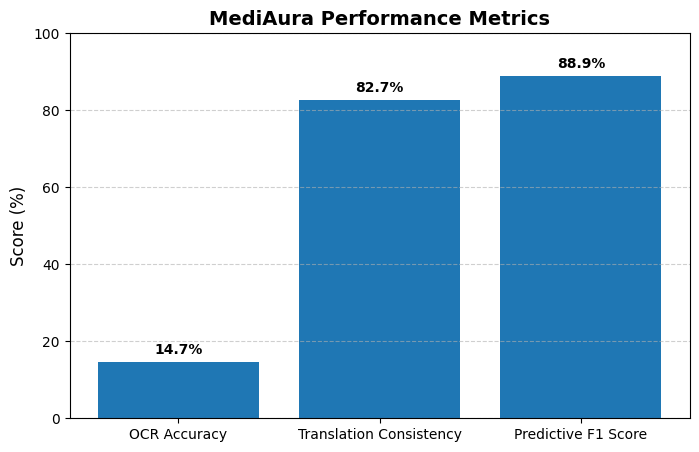

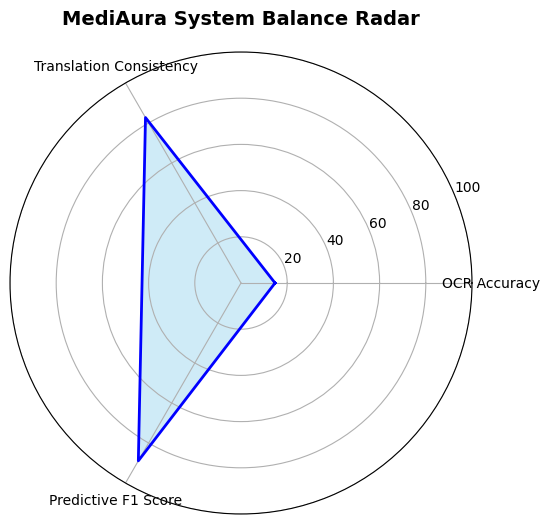

🏁 Overall MediAura Performance Score: 57.37/100


In [ ]:
# ==========================================
# STEP: Visualize Performance Metrics
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Data from previous evaluation
metrics = ['OCR Accuracy', 'Translation Consistency', 'Predictive F1 Score']
values = [ocr_accuracy, translation_consistency, f1 * 100]

# ---------- BAR CHART ----------
plt.figure(figsize=(8, 5))
plt.bar(metrics, values)
plt.title('MediAura Performance Metrics', fontsize=14, weight='bold')
plt.ylabel('Score (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(values):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=10, fontweight='bold')
plt.show()

# ---------- RADAR CHART ----------
# Prepare data for radar
labels = np.array(metrics)
stats = np.array(values)
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
stats = np.concatenate((stats, [stats[0]]))  # close the polygon
angles = np.concatenate((angles, [angles[0]]))

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, stats, 'b-', linewidth=2)
ax.fill(angles, stats, 'skyblue', alpha=0.4)
ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
ax.set_ylim(0, 100)
ax.set_title('MediAura System Balance Radar', fontsize=14, weight='bold', pad=20)
ax.grid(True)
plt.show()

# ---------- OVERALL SCORE DISPLAY ----------
print(f"🏁 Overall MediAura Performance Score: {overall_score:.2f}/100")
